Sydney Thompson
Part 1: About Me

1. Why are you pursuing the MSBA program?

I am pursuing the MSBA program because I wanted to build on the mathematics and computer science knowledge that I learned at Oregon State. I wanted to broaden out (I did biological research in the past, and didn't really enjoy it) and focus more on applying my knowledge and skills to make business decisions. 

2. What did you do before entering the program?

Before entering this program, I was completing my undergraduate education at Oregon State University. I was a Biological Data Sciences major with an option in Computational Biology. I also minored in Statistics. I graduated in June 2025.
 
3. What type of role, industry, or company are you interested in after graduation?

I am interested in data analyst/ data scientist roles after graduation. I would also be interested in business analyst roles. As for the industry, I'm interested in the technology sector but that could change.

4. What topics or methods are you most interested in learning in this course?

I'm interested in learning more about the neural networks and ensembling. In general, I'm curious to learn more about how to incorporate machine learning into making decisions.



Part 2: Cost of Living and Salary

Use Python to create an estimate of your expected cost of living for three different locations where you might want to live after completing the MSBA program. This should be compared with your salary needs as well as your desired salary (which may vary by location). Your notebook should include:

- Monthly cost of living broken into categories (e.g., housing, food, transportation)

- A calculation of:
  - minimum annual salary needed
  - desired (target) salary

You are welcome to include additional data if it helps support your analysis or visualization.

Requirements:
- At least 5 variables
- At least 2 calculations
- One organized data structure (dataframe, dictionary, etc).
- One simple plot

Your code should be structured so that:
- key inputs (e.g., rent, salary assumptions) are clearly defined
- changing those inputs and re-running the notebook updates all results correctly


In [21]:
import pandas as pd

cost_liv_dataset = pd.read_csv('archive/cost_of_living_us.csv')
cost_liv_dataset.head()

,case_id,state,isMetro,areaname,county,family_member_count,housing_cost,food_cost,transportation_cost,healthcare_cost,other_necessities_cost,childcare_cost,taxes,total_cost,median_family_income
0,1,AL,True,"Montgomery, AL MSA",Autauga County,1p0c,8505.72876,3454.91712,10829.16876,5737.47984,4333.81344,0.0000,6392.94504,39254.0532,73010.414062
1,1,AL,True,"Montgomery, AL MSA",Autauga County,1p1c,12067.50240,5091.70788,11588.19288,8659.55640,6217.45896,6147.8298,7422.07836,57194.3256,73010.414062
2,1,AL,True,"Montgomery, AL MSA",Autauga County,1p2c,12067.50240,7460.20308,12361.77720,11581.63260,7075.65816,15824.6940,9769.56228,76141.0308,73010.414062
3,1,AL,True,"Montgomery, AL MSA",Autauga County,1p3c,15257.15040,9952.23924,13452.18600,14503.70760,9134.35620,18802.1892,13101.70320,94203.5328,73010.414062
4,1,AL,True,"Montgomery, AL MSA",Autauga County,1p4c,15257.15040,12182.21400,13744.59840,17425.78560,9942.36396,18802.1892,13469.21880,100823.5200,73010.414062


In [ ]:
selected_counties = [
    "Marin County",
    "San Mateo County",
    "San Francisco County"
]

df = cost_liv_dataset[cost_liv_dataset["county"].isin(selected_counties)]
df.head()

,case_id,state,isMetro,areaname,county,family_member_count,housing_cost,food_cost,transportation_cost,healthcare_cost,other_necessities_cost,childcare_cost,taxes,total_cost,median_family_income
2060,207,CA,True,"San Francisco, CA HUD Metro FMR Area",Marin County,1p0c,28378.8228,4782.93312,11735.3760,5612.37996,12015.8112,0.0000,16706.1984,79231.524,157777.984375
2061,207,CA,True,"San Francisco, CA HUD Metro FMR Area",Marin County,1p1c,42906.3660,7048.88088,12979.5108,8418.70896,18100.7580,13996.9176,26921.9532,130373.100,157777.984375
2062,207,CA,True,"San Francisco, CA HUD Metro FMR Area",Marin County,1p2c,42906.3660,10327.78932,14280.2640,11225.03904,19288.8336,21446.9280,30490.9836,149966.208,157777.984375
2063,207,CA,True,"San Francisco, CA HUD Metro FMR Area",Marin County,1p3c,55151.5248,13777.72560,15281.5032,14031.36720,24975.7884,23739.2388,40014.7356,186971.880,157777.984375
2064,207,CA,True,"San Francisco, CA HUD Metro FMR Area",Marin County,1p4c,55151.5248,16864.86720,17743.3212,16837.69800,26094.3804,23739.2388,42819.6564,199250.700,157777.984375


In [ ]:
df_model = pd.DataFrame({
    "location": df["county"],
    
    # mapping categories
    "housing": df["housing_cost"],
    "food": df["food_cost"],
    "transportation": df["transportation_cost"],
    "healthcare": df["healthcare_cost"],
    
    # expenses
    "utilities": 500,
    "entertainment": 450,
    "miscellaneous": 650,
    
    # for calculations
    "savings_rate": 0.20,
    "tax_buffer": 1.50,
    "target_multiplier": 1.25
})

df_model.set_index("location")
df_model.head()

,location,housing,food,transportation,healthcare,utilities,entertainment,miscellaneous,savings_rate,tax_buffer,target_multiplier
2060,Marin County,28378.8228,4782.93312,11735.3760,5612.37996,500,450,650,0.2,1.5,1.25
2061,Marin County,42906.3660,7048.88088,12979.5108,8418.70896,500,450,650,0.2,1.5,1.25
2062,Marin County,42906.3660,10327.78932,14280.2640,11225.03904,500,450,650,0.2,1.5,1.25
2063,Marin County,55151.5248,13777.72560,15281.5032,14031.36720,500,450,650,0.2,1.5,1.25
2064,Marin County,55151.5248,16864.86720,17743.3212,16837.69800,500,450,650,0.2,1.5,1.25


In [ ]:
expense_cols = [
    "housing", "food", "transportation",
    "healthcare", "utilities", "entertainment", "miscellaneous"
]

# monthly total
df_model["monthly_total"] = df_model[expense_cols].sum(axis=1)

# minimum take-home needed
df_model["min_monthly_takehome"] = (df_model["monthly_total"] / (1 - df_model["savings_rate"]))

# minimum annual salary
df_model["minimum_salary"] = (df_model["min_monthly_takehome"] * 12 * df_model["tax_buffer"])

# desired salary
df_model["desired_salary"] = (df_model["minimum_salary"] * df_model["target_multiplier"])

df_model.head()

,location,housing,food,transportation,healthcare,utilities,entertainment,miscellaneous,savings_rate,tax_buffer,target_multiplier,monthly_total,min_monthly_takehome,minimum_salary,desired_salary
2060,Marin County,28378.8228,4782.93312,11735.3760,5612.37996,500,450,650,0.2,1.5,1.25,52109.51188,65136.88985,1.172464e+06,1.465580e+06
2061,Marin County,42906.3660,7048.88088,12979.5108,8418.70896,500,450,650,0.2,1.5,1.25,72953.46664,91191.83330,1.641453e+06,2.051816e+06
2062,Marin County,42906.3660,10327.78932,14280.2640,11225.03904,500,450,650,0.2,1.5,1.25,80339.45836,100424.32295,1.807638e+06,2.259547e+06
2063,Marin County,55151.5248,13777.72560,15281.5032,14031.36720,500,450,650,0.2,1.5,1.25,99842.12080,124802.65100,2.246448e+06,2.808060e+06
2064,Marin County,55151.5248,16864.86720,17743.3212,16837.69800,500,450,650,0.2,1.5,1.25,108197.41120,135246.76400,2.434442e+06,3.043052e+06


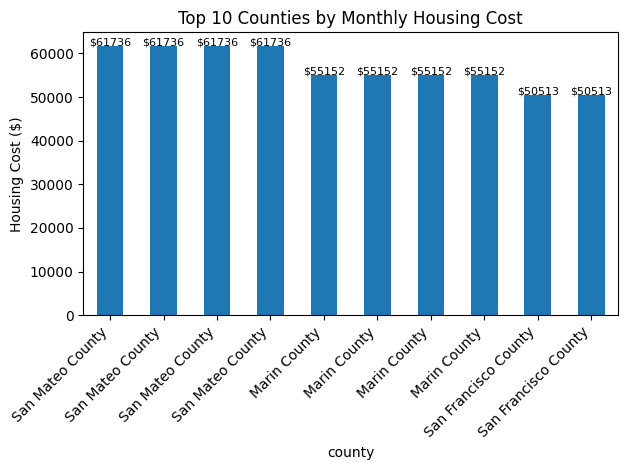

In [25]:
import matplotlib.pyplot as plt

top10 = cost_liv_dataset.sort_values(by="housing_cost", ascending=False).head(10)
top10

ax = top10.set_index("county")["housing_cost"].plot(kind="bar")

plt.title("Top 10 Counties by Monthly Housing Cost")
plt.ylabel("Housing Cost ($)")
plt.xticks(rotation=45, ha="right")

# adding labels
for i, value in enumerate(top10["housing_cost"]):
    ax.text(i, value + 50, f"${value:.0f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Part 3: Reflection

1. Did your notebook run successfully from start to finish?

Yes, it did run successfully from start to finish.

2. How long did this assignment take you?

This assignment took me around an hour. It took me a while to make sure that the calculations were correct. In addition, I was experimenting with the aesthetics for the plot.

3. What is one technical skill you feel confident about, and one you want to strengthen?

I feel confident about using the pandas packages and knowing which functions I want to use. I want to strengthen my data manipulation skills, especially when using them to create larger dataframes.